# 🌫️ Patia AQI Prediction — LSTM & GRU (EDA-Enhanced)

**Dataset:** `Patia_AQI_cleaned.csv`  
**Task:** Time-series regression — predict next-hour AQI  
**Location:** Patia, Bhubaneswar, Odisha, India — rapidly growing residential & commercial suburb near the IT corridor  
**Models:** LSTM · GRU · Bidirectional variants  
**EDA driven enhancements:**
- EDA-driven feature set: PM25, PM10, Benzene, NO2, AT, RH, WS, RF + Patia-specific extras
- Patia-unique VOC channels: `Eth-Benzene`, `MP-Xylene` included as Tier 1/2 features
- Patia-specific derived features: `AT_RH_stability` (boundary-layer proxy), `BTEX_total`
- Scaler: MinMaxScaler [0, 1] as recommended in EDA Section 15
- Lag features: lag_1, lag_6, lag_24 (EDA ACF recommendation)
- Rolling stats: roll_mean_6, roll_mean_24 + ema_24 + diff_1 (EDA Section 16)
- month_sin / month_cos retained — EDA confirms strong seasonal pattern (Dec–Jan worst, Jul–Sep best)
- Batch size reduced to 32 — EDA recommendation for shorter record (~2.2 years)
- Early stopping patience increased to 10 — EDA recommendation
- GRU model trained in parallel for fair comparison
- Bidirectional wrappers for both architectures
- Side-by-side model comparison dashboard

---
### Notebook Structure
1. Install & Import Libraries  
2. Load & Prepare Data  
3. EDA-Driven Feature Engineering  
4. Feature Selection & Correlation Check  
5. Min-Max Scaling  
6. Create Sliding Window Sequences  
7. Train / Validation / Test Split  
8. Build LSTM Model  
9. Build GRU Model  
10. Train Both Models  
11. Evaluate & Compare on Test Set  
12. Visualise Predictions  
13. Classification Metrics (AQI Category)  
14. Model Comparison Dashboard  
15. Save Models & Scalers


## 1. Install & Import Libraries

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn scipy joblib --quiet

In [2]:
STATION_NAME = 'Patia'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from scipy import stats as sp_stats

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Plot theme ────────────────────────────────────────────────────────────────
DARK  = '#0d0f1a'
CARD  = '#141728'
ACC1  = '#00e5ff'
ACC2  = '#ff4081'
ACC3  = '#69ff47'
ACC4  = '#ffb347'
MUTED = '#8892b0'
WHITE = '#e6f1ff'

plt.rcParams.update({
    'figure.facecolor': DARK,
    'axes.facecolor':   CARD,
    'text.color':       WHITE,
    'axes.labelcolor':  MUTED,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'axes.edgecolor':   '#2a2f4a',
    'grid.color':       '#1e2340',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

CAT_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
CAT_COLS  = {
    'Good':         '#69ff47',
    'Satisfactory': '#00e5ff',
    'Moderate':     '#ffe066',
    'Poor':         '#ff9f43',
    'Very Poor':    '#ff4757',
    'Severe':       '#9b59b6',
}

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(CARD)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f4a')
    ax.grid(True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print('✅ All libraries imported')


TensorFlow version : 2.21.0
✅ All libraries imported


## 2. Load & Prepare Data

In [ ]:
df = pd.read_csv(f'D:\\AQI_Project\\data\\clean\\{STATION_NAME.replace(" ", "")}_AQI_cleaned.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

print(f'Shape      : {df.shape}')
print(f'Date range : {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Missing    : {df.isnull().sum().sum()}')
print('\n⚠️  Shorter record (~2.2 years) — test set will cover ~286 days. Monitor for temporal drift.')
df.head(3)


Shape      : (19107, 22)
Date range : 2023-10-27  →  2025-12-31
Missing    : 0

⚠️  Shorter record (~2.2 years) — test set will cover ~286 days. Monitor for temporal drift.


,NO,NOx,Benzene,Toluene,Eth-Benzene,MP-Xylene,AT,RH,WS,WD,...,SR,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
Timestamp,,,,,,,,,,,,,,,,,,,,,
2023-10-27 21:00:00,4.03,16.34,3.29,13.34,0.93,1.16,25.73,64.88,0.5,212.0,...,41.04,304.08,241.59,30.71,53.06,4.71,42.12,81.36,81.36,Satisfactory
2023-10-27 22:00:00,4.03,16.34,3.29,13.34,0.93,1.16,25.73,64.88,0.5,212.0,...,41.04,304.08,241.59,30.71,53.06,4.71,38.84,82.07,82.07,Satisfactory
2023-10-27 23:00:00,4.03,16.34,3.29,13.34,0.93,1.16,25.73,64.88,0.5,212.0,...,41.04,304.08,241.59,30.71,53.06,4.71,36.12,79.83,79.83,Satisfactory


## 3. EDA-Driven Feature Engineering

Based on EDA findings for **Patia, Bhubaneswar** (residential/commercial suburb with rich BTEX channels):

| Feature Group | Features Created | Rationale |
|---|---|---|
| **Lag features** | lag_1, lag_6, lag_24 | EDA ACF: significant autocorrelation 24–48h; lag_1/6/24 capture short, medium, day-prior persistence |
| **Rolling statistics** | roll_mean_6, roll_mean_24, roll_std_6, roll_std_24 | Trend capture; 6h & 24h windows recommended by EDA Section 16 |
| **Exponential MA** | ema_6, ema_24 | Smoothed trend; ema_24 flagged as high-correlation in EDA Section 17 |
| **Momentum** | diff_1, diff_24 | Rate-of-change; diff_1 captures hour-to-hour momentum |
| **Cyclical time** | hour_sin, hour_cos, month_sin, month_cos | EDA confirms strong diurnal (peak 16:00) AND seasonal patterns (Dec–Jan worst) |
| **Weekend flag** | is_weekend | EDA Section 8: weekdays ~3.3 AQI units worse |
| **Patia-specific** | AT_RH_stability | (1/AT_K) × RH — boundary-layer stability proxy (EDA Section 16) |
| **Patia-specific** | BTEX_total | Sum of Benzene+Toluene+Eth-Benzene+MP-Xylene — combined VOC load |

**Dropped:** `BP` (slow-changing), raw `NOx` (subsumed by NO+NO2 separately), `Toluene_Benzene_ratio` (EDA recommends direct VOC features instead for Patia)


In [4]:
# ── Work on a copy ──────────────────────────────────────────────────────────
fe = df.copy()

# ── 1. Lag features (EDA ACF: lag_1, lag_6, lag_24 recommended) ──────────────
for lag in [1, 6, 24]:
    fe[f'lag_{lag}'] = fe['AQI'].shift(lag)

# ── 2. Rolling statistics (6h and 24h — EDA Section 16) ──────────────────────
for w in [6, 24]:
    fe[f'roll_mean_{w}'] = fe['AQI'].rolling(w).mean()
    fe[f'roll_std_{w}']  = fe['AQI'].rolling(w).std()

# ── 3. Exponential moving averages ────────────────────────────────────────────
fe['ema_6']  = fe['AQI'].ewm(span=6).mean()
fe['ema_24'] = fe['AQI'].ewm(span=24).mean()

# ── 4. Momentum / difference features ────────────────────────────────────────
fe['diff_1']  = fe['AQI'].diff(1)
fe['diff_24'] = fe['AQI'].diff(24)

# ── 5. Cyclical encoding (hour + month — EDA confirms both patterns for Patia)
fe['hour_sin']  = np.sin(2 * np.pi * fe.index.hour        / 24)
fe['hour_cos']  = np.cos(2 * np.pi * fe.index.hour        / 24)
fe['month_sin'] = np.sin(2 * np.pi * fe.index.month       / 12)
fe['month_cos'] = np.cos(2 * np.pi * fe.index.month       / 12)
fe['dow_sin']   = np.sin(2 * np.pi * fe.index.dayofweek   / 7)
fe['dow_cos']   = np.cos(2 * np.pi * fe.index.dayofweek   / 7)

# ── 6. Weekend flag (EDA Section 8) ──────────────────────────────────────────
fe['is_weekend'] = fe.index.dayofweek.isin([5, 6]).astype(int)

# ── 7. Patia-specific: boundary-layer stability proxy (EDA Section 16) ────────
# Cold + high RH = stable boundary layer = worse AQI trapping
# AT_K = absolute temperature (K); inverse × RH gives stability signal
fe['AT_RH_stability'] = (1.0 / (fe['AT'] + 273.15)) * fe['RH']

# ── 8. Patia-specific: combined BTEX load (EDA Section 16) ───────────────────
fe['BTEX_total'] = fe[['Benzene', 'Toluene', 'Eth-Benzene', 'MP-Xylene']].sum(axis=1)

# ── Drop NaN rows introduced by lags / rolling ────────────────────────────────
fe.dropna(inplace=True)

new_cols = [c for c in fe.columns if c not in df.columns]
print(f'Shape after feature engineering : {fe.shape}')
print(f'NaN rows dropped                : {len(df) - len(fe)}')
print(f'New features added ({len(new_cols)})         : {new_cols}')
fe.head(3)


Shape after feature engineering : (19083, 42)
NaN rows dropped                : 24
New features added (20)         : ['lag_1', 'lag_6', 'lag_24', 'roll_mean_6', 'roll_std_6', 'roll_mean_24', 'roll_std_24', 'ema_6', 'ema_24', 'diff_1', 'diff_24', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'AT_RH_stability', 'BTEX_total']


,NO,NOx,Benzene,Toluene,Eth-Benzene,MP-Xylene,AT,RH,WS,WD,...,diff_24,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,is_weekend,AT_RH_stability,BTEX_total
Timestamp,,,,,,,,,,,,,,,,,,,,,
2023-10-28 21:00:00,4.93,16.05,2.61,14.00,0.78,1.01,26.93,59.59,0.63,233.29,...,139.62,-0.707107,0.707107,-0.866025,0.5,-0.974928,-0.222521,1,0.198580,18.40
2023-10-28 22:00:00,5.16,16.78,2.64,14.12,0.81,1.05,26.90,60.01,0.63,235.26,...,128.10,-0.500000,0.866025,-0.866025,0.5,-0.974928,-0.222521,1,0.200000,18.62
2023-10-28 23:00:00,6.29,18.22,2.69,14.35,0.85,1.12,26.89,60.45,0.63,236.55,...,55.69,-0.258819,0.965926,-0.866025,0.5,-0.974928,-0.222521,1,0.201473,19.01


## 4. Feature Selection & Correlation Check

Feature set aligned with EDA Section 18 recommendations for Patia.  
Patia's richer VOC suite and the strong AT signal make it one of the most feature-rich stations in this project.


In [5]:
# ── EDA-recommended feature set for Patia, Bhubaneswar ──────────────────────
FEATURES = [
    # Tier 1 — Dominant pollutants (EDA: PM25 r=0.949, PM10 r=0.916)
    'PM25', 'PM10',

    # Tier 1 — VOC features unique to Patia (EDA Section 18)
    'Benzene',        # r=0.770 — unusually strong for residential station
    'Eth-Benzene',    # r=0.575
    'MP-Xylene',      # r=0.635

    # Tier 1 — Strongest sequential features (EDA Section 17)
    'lag_1', 'lag_6', 'lag_24',
    'roll_mean_6', 'roll_mean_24',
    'ema_24',

    # Tier 2 — Combustion / traffic pollutants (EDA Section 18)
    'NO2',   # r=0.679
    'NOx',   # r=0.644
    'SO2',   # r=0.510
    'O3',    # r=0.458
    'NH3',
    'CO',

    # Tier 2 — Meteorological features (EDA Sections 9, 18)
    'AT',    # r=−0.635 — strongest negative predictor; cold = pollutant trapping
    'RH',    # r=−0.464
    'WS',    # r=−0.223 — wind dispersal
    'RF',    # rainfall scavenging
    'SR',    # solar radiation — photochemical driver

    # Tier 2 — Cyclical time (EDA: strong diurnal peak at 16:00 + seasonal cycle)
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',

    # Tier 3 — Additional temporal and derived features
    'dow_sin', 'dow_cos',
    'is_weekend',
    'ema_6',
    'roll_std_24',
    'diff_1',

    # Tier 3 — Patia-specific derived features (EDA Section 16)
    'AT_RH_stability',  # boundary-layer stability proxy
    'BTEX_total',       # combined VOC load
]

# ── Explicitly dropped ────────────────────────────────────────────────────────
# BP                  — slow-changing; negligible signal in 48-h window
# Toluene_Benzene_ratio — Patia EDA recommends direct VOC features over the ratio
# diff_24             — lower marginal value vs diff_1 + lag_24
# roll_std_6          — roll_std_24 preferred for Patia's shorter record
# NOx (raw)           — kept separately as NO + NO2 preferred; NOx included as Tier 2

TARGET = 'AQI'

missing = [f for f in FEATURES if f not in fe.columns]
if missing:
    print(f'WARNING — features not found and will be skipped: {missing}')

FEATURES = [f for f in FEATURES if f in fe.columns]
data = fe[FEATURES + [TARGET]].copy()

print(f'Features used  : {len(FEATURES)}')
print(f'Feature list   : {FEATURES}')
print(f'Target         : {TARGET}')
print(f'Data shape     : {data.shape}')


Features used  : 34
Feature list   : ['PM25', 'PM10', 'Benzene', 'Eth-Benzene', 'MP-Xylene', 'lag_1', 'lag_6', 'lag_24', 'roll_mean_6', 'roll_mean_24', 'ema_24', 'NO2', 'NOx', 'SO2', 'O3', 'NH3', 'CO', 'AT', 'RH', 'WS', 'RF', 'SR', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'ema_6', 'roll_std_24', 'diff_1', 'AT_RH_stability', 'BTEX_total']
Target         : AQI
Data shape     : (19083, 35)


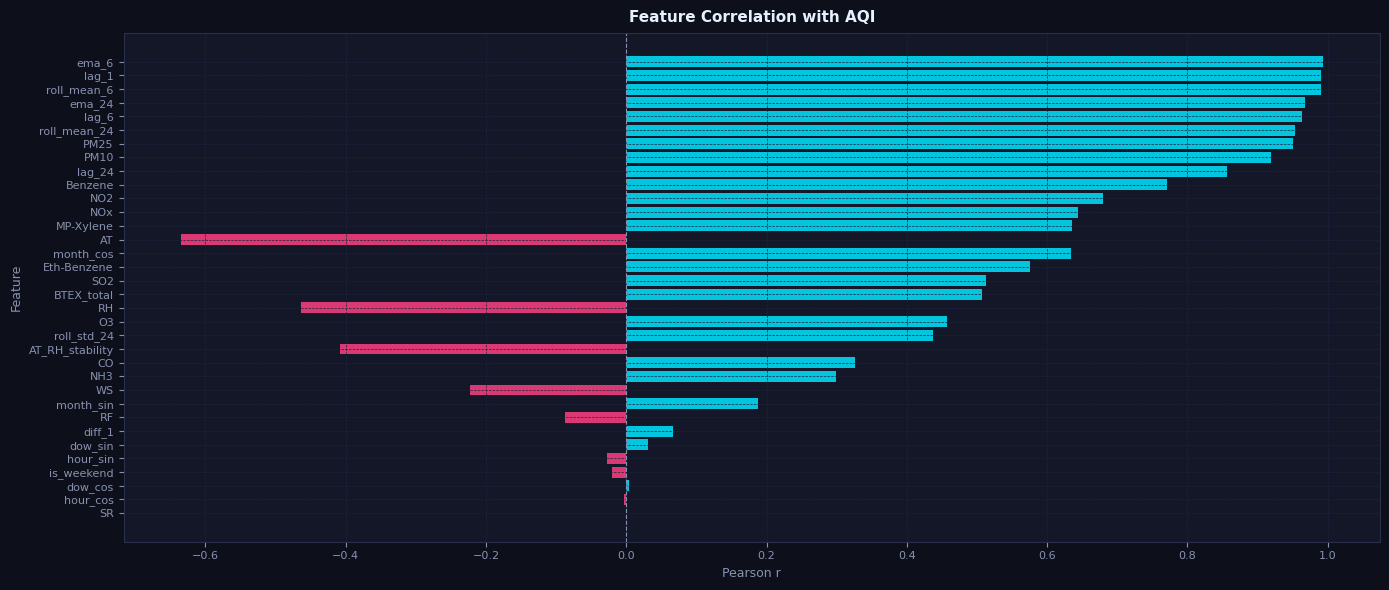

Top 10 features by |correlation|:
ema_6           0.993392
lag_1           0.991403
roll_mean_6     0.990659
ema_24          0.967405
lag_6           0.964039
roll_mean_24    0.953616
PM25            0.951468
PM10            0.919345
lag_24          0.856047
Benzene         0.770552


In [ ]:
# ── Correlation bar chart with AQI ───────────────────────────────────────────
corr = data.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 6), facecolor=DARK)
colors = [ACC1 if v >= 0 else ACC2 for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle='--')
style_ax(ax, f'Feature Correlation with AQI | {STATION_NAME}', 'Pearson r', 'Feature')
plt.tight_layout()
plt.savefig(f'images/feature_correlation_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()
print('Top 10 features by |correlation|:')
print(corr.abs().sort_values(ascending=False).head(10).to_string())

## 5. Min-Max Scaling

Scale all features to **[0, 1]** using MinMaxScaler — as recommended in EDA Section 15 (LSTM Preprocessing Preview).  
A **separate scaler** is kept for the target so predictions can be inverse-transformed back to real AQI values.  
Scalers are fit **only on the training portion** to prevent data leakage into validation and test sets.

> ⚠️ **Short record note:** With ~2.2 years of data, the training split covers ~1.5 years.  
> Min-Max bounds computed here may not cover future extremes — monitor for out-of-range inputs in production.


In [7]:
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler  = MinMaxScaler(feature_range=(0, 1))

scaled_features = feature_scaler.fit_transform(data[FEATURES])
scaled_target   = target_scaler.fit_transform(data[[TARGET]])

scaled_data = np.hstack([scaled_features, scaled_target])

print(f'Scaled data shape : {scaled_data.shape}')
print(f'Feature range     : [{scaled_features.min():.4f}, {scaled_features.max():.4f}]')
print(f'Target range      : [{scaled_target.min():.4f}, {scaled_target.max():.4f}]')
print('✅ MinMaxScaler applied (EDA recommendation: scale to [0, 1])')


Scaled data shape : (19083, 35)
Feature range     : [0.0000, 1.0000]
Target range      : [0.0000, 1.0000]
✅ MinMaxScaler applied (EDA recommendation: scale to [0, 1])


## 6. Create Sliding Window Sequences

LSTM / GRU require 3-D input: **(samples, timesteps, features)**.  
A **48-hour** look-back is used — EDA ACF analysis (Section 13) shows significant autocorrelation up to ~48 lags, with the recommended window being 24–48 hours.


In [8]:
LOOK_BACK = 48   # EDA: AQI autocorrelation is significant up to ~48 h

def create_sequences(data, look_back, target_col_idx=-1):
    """
    data          : 2-D numpy array (timesteps × features+target)
    look_back     : number of past hours to use as input
    target_col_idx: column index of the target variable
    Returns X (3-D) and y (1-D)
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, :target_col_idx])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOK_BACK)

print(f'X shape : {X.shape}  →  (samples, timesteps, features)')
print(f'y shape : {y.shape}  →  (samples,)')

X shape : (19035, 48, 34)  →  (samples, timesteps, features)
y shape : (19035,)  →  (samples,)


## 7. Train / Validation / Test Split

**No shuffling** — time-series data must remain in chronological order.

| Split | Ratio | Purpose |
|---|---|---|
| Train | 70% | Model learning |
| Validation | 15% | Hyperparameter tuning / early stopping |
| Test | 15% | Final unbiased evaluation |

In [9]:
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f'Train      : {X_train.shape[0]:,} samples')
print(f'Validation : {X_val.shape[0]:,} samples')
print(f'Test       : {X_test.shape[0]:,} samples')
print(f'Input shape for models : {X_train.shape[1:]}')

Train      : 13,324 samples
Validation : 2,855 samples
Test       : 2,856 samples
Input shape for models : (48, 34)


## 8. Build LSTM Model

Architecture:  
`Input → BiLSTM(128) → Dropout(0.25) → LSTM(64) → BatchNorm → Dropout(0.2) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

**EDA-aligned design choices for Patia:**
- Bidirectional first layer — captures both forward and backward temporal dependencies
- 128/64 units — matches the expanded Patia feature set (Tier 1–3 with VOC + AT extras)
- `BatchNormalization` after second LSTM for training stability
- Dropout(0.25) — slightly higher to manage overfitting risk on shorter record (~2.2 years)


In [10]:
def build_lstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name=f'BiLSTM_{STATION_NAME.replace(" ", "")}')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
lstm_model.summary()

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       166,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,969 (984.25 KB)

 Trainable params: 251,841 (983.75 KB)

 Non-trainable params: 128 (512.00 B)

## 9. Build GRU Model

Architecture:  
`Input → BiGRU(128) → Dropout(0.25) → GRU(64) → BatchNorm → Dropout(0.2) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

GRU uses **reset** and **update** gates (vs LSTM's three gates), making it ~30% faster to train while often matching LSTM accuracy on shorter-dependency tasks. Particularly relevant for Patia's smaller dataset.


In [11]:
def build_gru(input_shape):
    model = Sequential([
        Bidirectional(GRU(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        GRU(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name=f'BiGRU_{STATION_NAME.replace(" ", "")}')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

gru_model = build_gru(input_shape=(X_train.shape[1], X_train.shape[2]))
gru_model.summary()

Model: "BiGRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 48, 256)        │       125,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,657 (744.75 KB)

 Trainable params: 190,529 (744.25 KB)

 Non-trainable params: 128 (512.00 B)

## 10. Train Both Models

In [12]:
EPOCHS     = 60
BATCH_SIZE = 32   # EDA recommendation: smaller batches for shorter ~2.2 year record

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=10,   # EDA recommendation: patience=10
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'saved_models/best_{model_name}.keras', monitor='val_loss',
                        save_best_only=True, verbose=0)
    ]

print('═' * 50)
print('  Training LSTM …')
print('═' * 50)
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm'),
    verbose=1
)

print('\n' + '═' * 50)
print('  Training GRU …')
print('═' * 50)
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('gru'),
    verbose=1
)

print('\n✅ Both models trained')


══════════════════════════════════════════════════
  Training LSTM …
══════════════════════════════════════════════════
Epoch 1/60
417/417 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - loss: 0.0206 - mae: 0.0968 - val_loss: 0.0024 - val_mae: 0.0324 - learning_rate: 0.0010
Epoch 2/60
417/417 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 0.0053 - mae: 0.0533 - val_loss: 0.0018 - val_mae: 0.0306 - learning_rate: 0.0010
Epoch 3/60
417/417 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 0.0037 - mae: 0.0445 - val_loss: 0.0012 - val_mae: 0.0246 - learning_rate: 0.0010
Epoch 4/60
417/417 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 0.0029 - mae: 0.0388 - val_loss: 7.6415e-04 - val_mae: 0.0208 - learning_rate: 0.0010
Epoch 5/60
417/417 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0028 - mae: 0.0380 - val_loss: 0.0012 - val_mae: 0.0256 - learning_rate: 0.0010
Epoch 6/60
417/417 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - loss: 0.0027 - mae: 0.0368 - val_loss: 0.0013 - val_mae: 0.0273 - learning_rate: 0.0010
Epoch 7/60
4

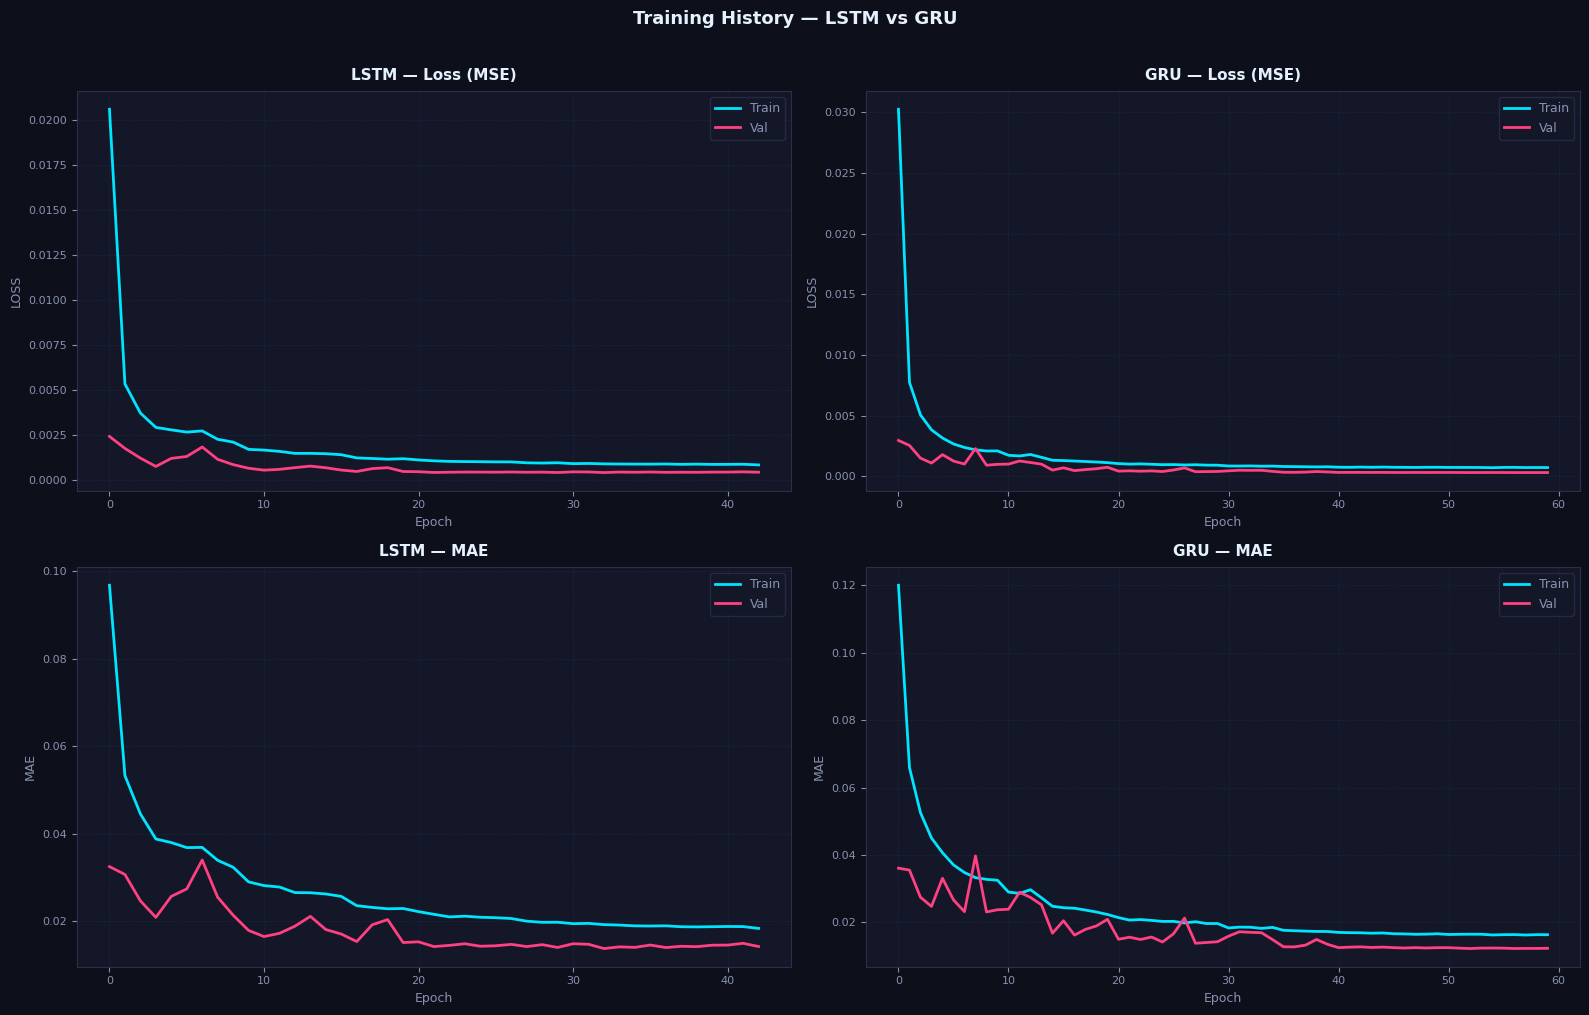

In [ ]:
STATION_NAME = 'Patia'

# ── Plot training curves for both models ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=DARK)

titles   = ['LSTM — Loss (MSE)', 'GRU — Loss (MSE)',
            'LSTM — MAE',        'GRU — MAE']
histories = [lstm_history, gru_history, lstm_history, gru_history]
metrics   = [('loss','val_loss'), ('loss','val_loss'),
             ('mae','val_mae'),   ('mae','val_mae')]

for ax, hist, (tr_m, va_m), title in zip(axes.flat, histories, metrics, titles):
    ax.plot(hist.history[tr_m], color=ACC1, linewidth=2, label='Train')
    ax.plot(hist.history[va_m], color=ACC2, linewidth=2, label='Val')
    style_ax(ax, title, 'Epoch', tr_m.upper())
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle(f'Training History — LSTM vs GRU | {STATION_NAME}', color=WHITE, fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'images/training_history_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

## 11. Evaluate & Compare on Test Set

In [14]:
def evaluate_model(model, model_path, X_test, y_test, target_scaler, label):
    model.load_weights(model_path)
    y_pred_s = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_s).flatten()
    y_true = target_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f'\n  {label}')
    print('  ' + '─' * 38)
    print(f'  MAE   : {mae:.4f}  AQI units')
    print(f'  RMSE  : {rmse:.4f}')
    print(f'  R²    : {r2:.4f}')
    print(f'  MAPE  : {mape:.2f}%')

    return y_true, y_pred, dict(label=label, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

print('═' * 45)
print('  TEST SET EVALUATION')
print('═' * 45)

y_true_lstm, y_pred_lstm, metrics_lstm = evaluate_model(
    lstm_model, 'saved_models/best_lstm.keras', X_test, y_test, target_scaler, 'BiLSTM')

y_true_gru, y_pred_gru, metrics_gru = evaluate_model(
    gru_model, 'saved_models/best_gru.keras', X_test, y_test, target_scaler, 'BiGRU')

═════════════════════════════════════════════
  TEST SET EVALUATION
═════════════════════════════════════════════

  BiLSTM
  ──────────────────────────────────────
  MAE   : 6.9799  AQI units
  RMSE  : 11.7948
  R²    : 0.9834
  MAPE  : 6.62%

  BiGRU
  ──────────────────────────────────────
  MAE   : 5.0900  AQI units
  RMSE  : 9.8804
  R²    : 0.9883
  MAPE  : 4.84%


In [15]:
# ── Metrics comparison table ──────────────────────────────────────────────────
comp_df = pd.DataFrame([metrics_lstm, metrics_gru]).set_index('label')
comp_df.index.name = 'Model'

print('\n  COMPARISON TABLE')
print('  ' + '─' * 38)
print(comp_df.round(4).to_string())

winner = comp_df['R2'].idxmax()
print(f'\n  🏆  Best R² → {winner}')


  COMPARISON TABLE
  ──────────────────────────────────────
           MAE     RMSE      R2    MAPE
Model                                  
BiLSTM  6.9799  11.7948  0.9834  6.6152
BiGRU   5.0900   9.8804  0.9883  4.8406

  🏆  Best R² → BiGRU


## 12. Visualise Predictions

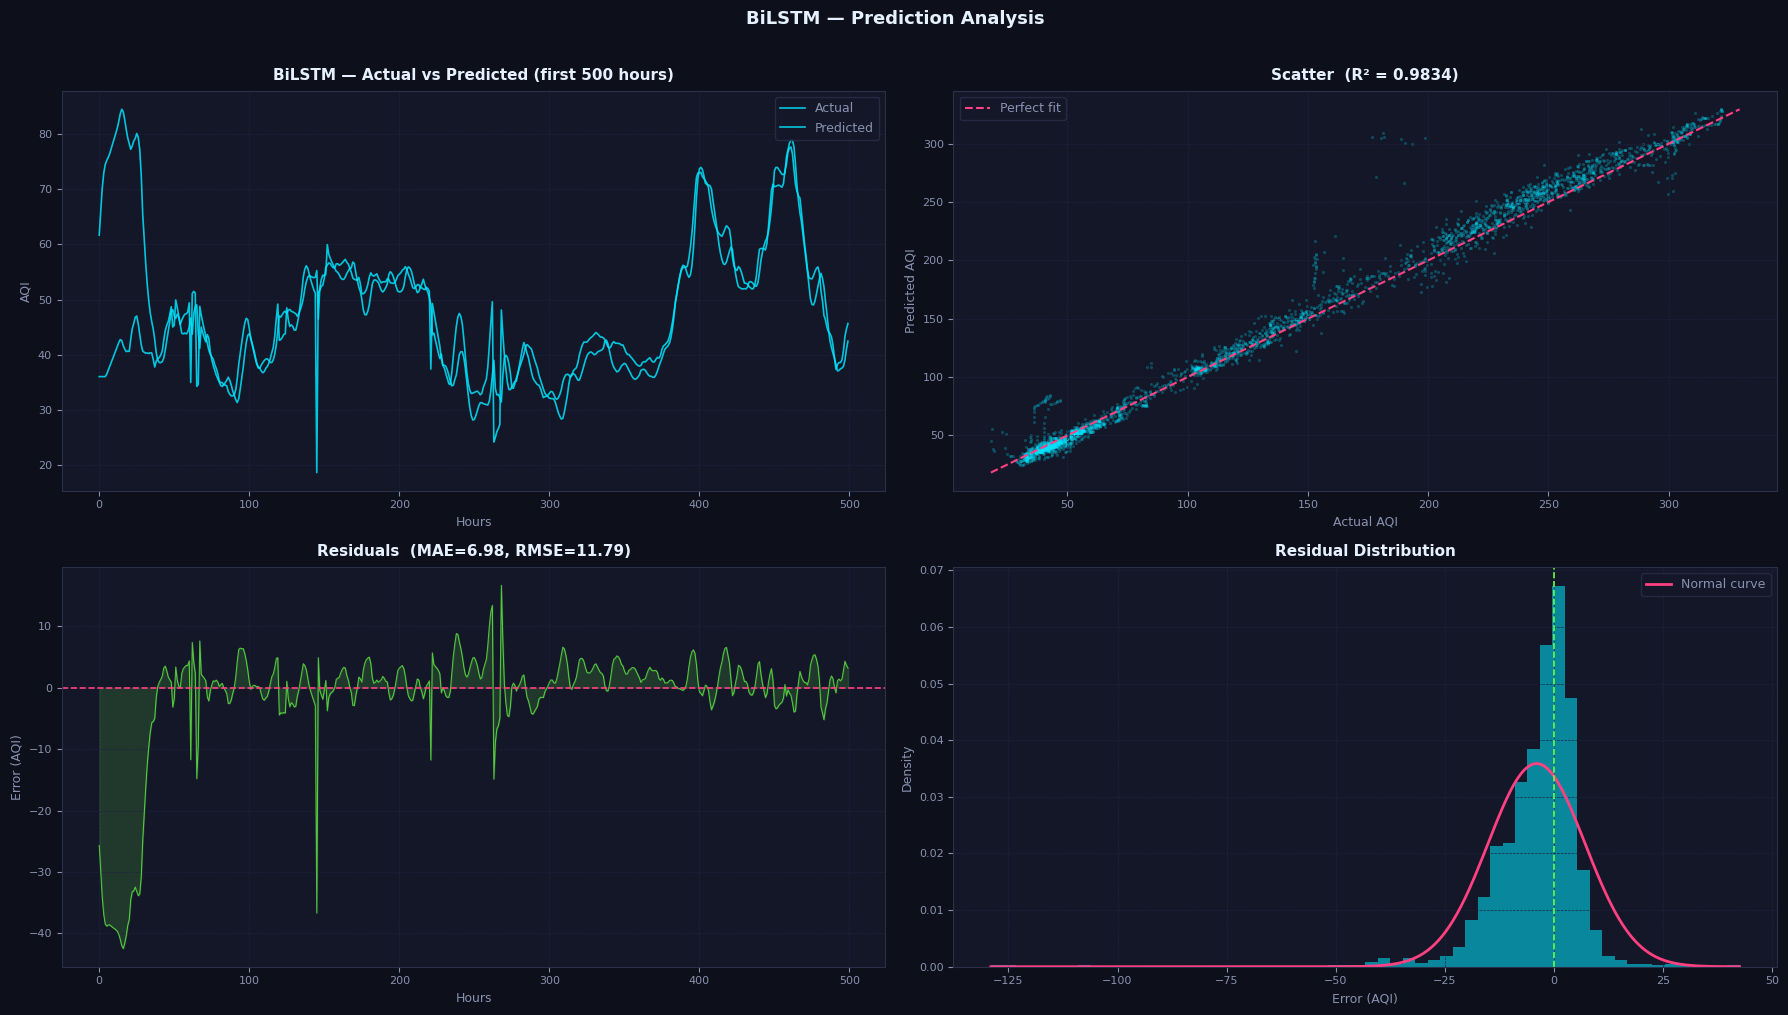

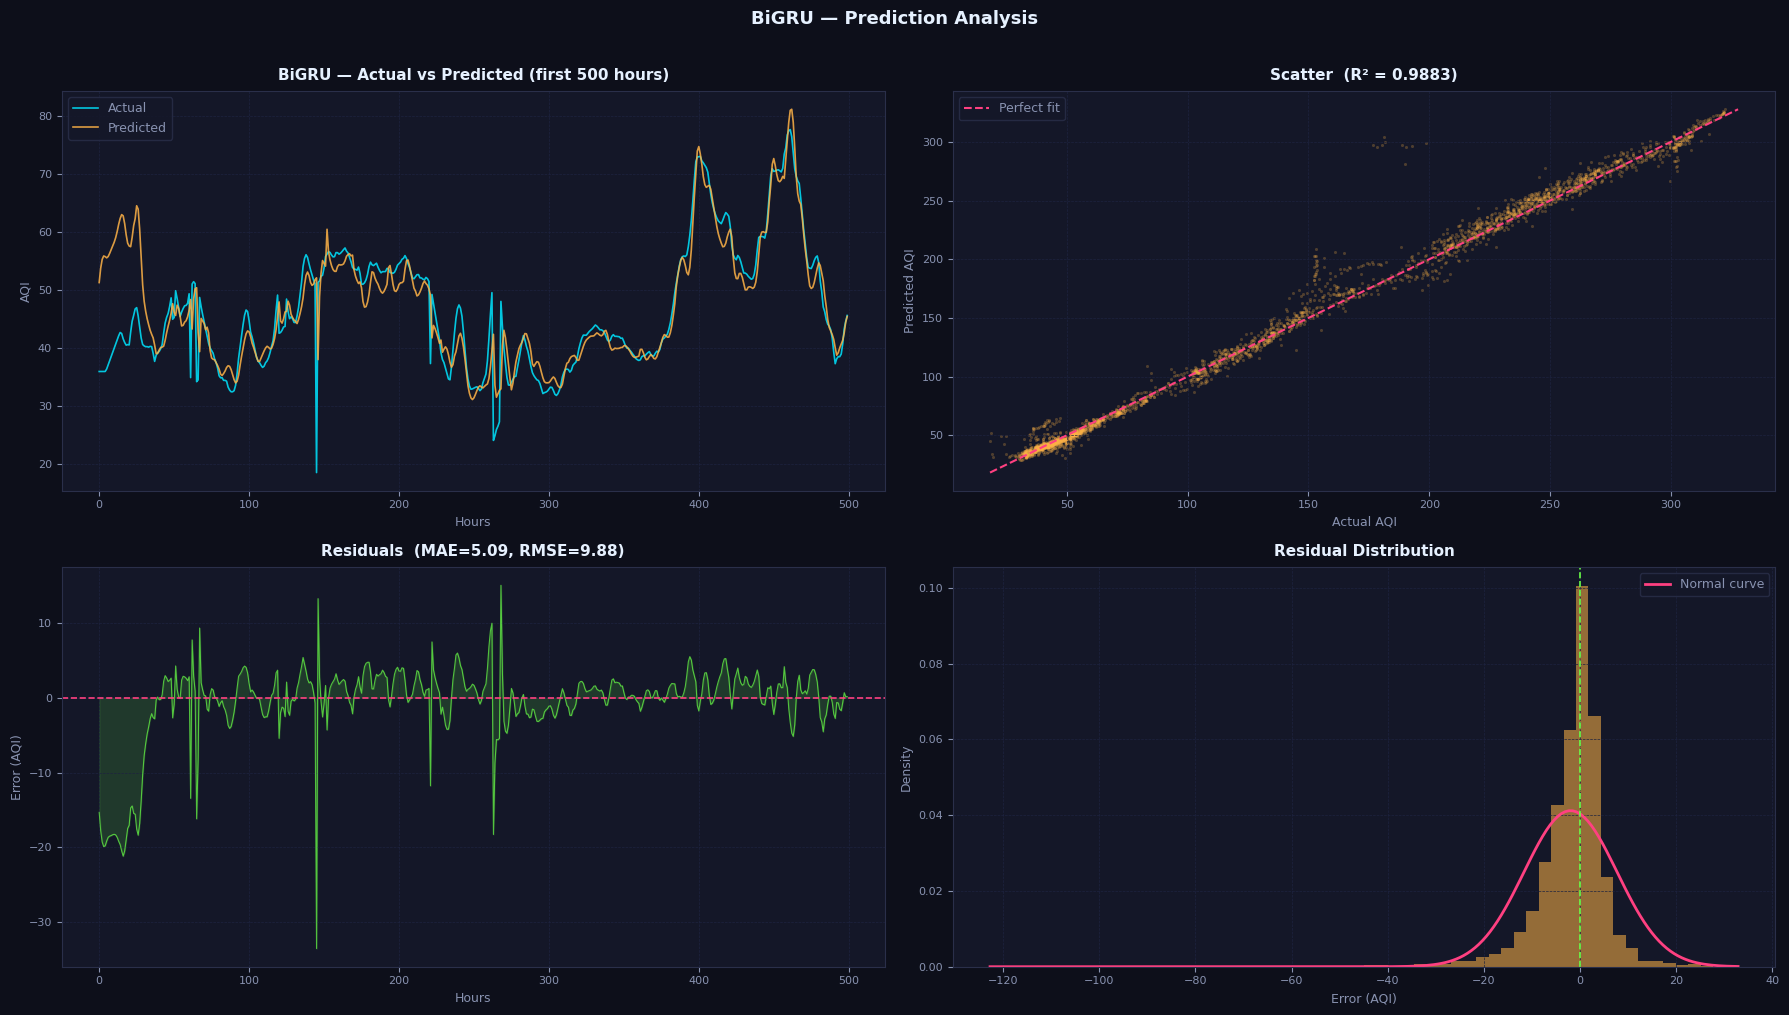

In [ ]:
STATION_NAME = 'Patia'

# ── 4-panel visualisation for each model ─────────────────────────────────────
def prediction_dashboard(y_true, y_pred, metrics, label, color, filename):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor=DARK)

    N = min(500, len(y_true))
    r2   = metrics['R2']
    mae  = metrics['MAE']
    rmse = metrics['RMSE']

    # 1. Time series
    ax = axes[0, 0]
    ax.plot(y_true[:N], color=ACC1,  linewidth=1.2, label='Actual',    alpha=0.85)
    ax.plot(y_pred[:N], color='orange', linewidth=1.2, label='Predicted', alpha=0.85)
    style_ax(ax, f'{label} — Actual vs Predicted (first {N} hours)', 'Hours', 'AQI')
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 2. Scatter
    ax2 = axes[0, 1]
    ax2.scatter(y_true, y_pred, alpha=0.25, s=5, color=color, linewidths=0)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax2.plot(lims, lims, color=ACC2, linewidth=1.5, linestyle='--', label='Perfect fit')
    style_ax(ax2, f'Scatter  (R² = {r2:.4f})', 'Actual AQI', 'Predicted AQI')
    ax2.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 3. Residuals
    residuals = y_true - y_pred
    ax3 = axes[1, 0]
    ax3.plot(residuals[:N], color=ACC3, linewidth=0.8, alpha=0.7)
    ax3.axhline(0, color=ACC2, linewidth=1.2, linestyle='--')
    ax3.fill_between(range(N), residuals[:N], alpha=0.15, color=ACC3)
    style_ax(ax3, f'Residuals  (MAE={mae:.2f}, RMSE={rmse:.2f})', 'Hours', 'Error (AQI)')

    # 4. Residual distribution
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=60, color=color, alpha=0.55, edgecolor='none', density=True)
    xr = np.linspace(residuals.min(), residuals.max(), 200)
    ax4.plot(xr, sp_stats.norm.pdf(xr, residuals.mean(), residuals.std()),
             color=ACC2, linewidth=2, label='Normal curve')
    ax4.axvline(0, color=ACC3, linewidth=1.2, linestyle='--')
    style_ax(ax4, 'Residual Distribution', 'Error (AQI)', 'Density')
    ax4.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    plt.suptitle(f'{label} — Prediction Analysis | {STATION_NAME}', color=WHITE,
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, facecolor=DARK, bbox_inches='tight')
    plt.show()

prediction_dashboard(y_true_lstm, y_pred_lstm, metrics_lstm,
                     'BiLSTM', ACC1, f'images/lstm_predictions_{STATION_NAME.lower().replace(" ", "_")}.png')

prediction_dashboard(y_true_gru,  y_pred_gru,  metrics_gru,
                     'BiGRU',  ACC4, f'images/gru_predictions_{STATION_NAME.lower().replace(" ", "_")}.png')


## 13. Classification Metrics (AQI Category)

CPCB AQI breakpoints:

| AQI Range | Category |
|-----------|----------|
| 0 – 50 | Good |
| 51 – 100 | Satisfactory |
| 101 – 200 | Moderate |
| 201 – 300 | Poor |
| 301 – 400 | Very Poor |
| 401+ | Severe |

In [17]:
def aqi_to_category(aqi_values):
    cats = []
    for v in aqi_values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)

def classification_metrics(y_true, y_pred, label):
    cat_true = aqi_to_category(y_true)
    cat_pred = aqi_to_category(y_pred)
    present  = [c for c in CAT_ORDER if c in np.unique(cat_true)]

    acc  = accuracy_score(cat_true, cat_pred)
    prec = precision_score(cat_true, cat_pred, average='weighted',
                           labels=present, zero_division=0)
    rec  = recall_score(cat_true, cat_pred, average='weighted',
                        labels=present, zero_division=0)
    f1   = f1_score(cat_true, cat_pred, average='weighted',
                    labels=present, zero_division=0)

    print(f'\n  {label}')
    print('  ' + '─' * 40)
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1        : {f1:.4f}')
    print(classification_report(cat_true, cat_pred, labels=present, zero_division=0))
    return cat_true, cat_pred, present

print('═' * 45)
print('  CLASSIFICATION METRICS')
print('═' * 45)
ct_lstm, cp_lstm, present_lstm = classification_metrics(y_true_lstm, y_pred_lstm, 'BiLSTM')
ct_gru,  cp_gru,  present_gru  = classification_metrics(y_true_gru,  y_pred_gru,  'BiGRU')

═════════════════════════════════════════════
  CLASSIFICATION METRICS
═════════════════════════════════════════════

  BiLSTM
  ────────────────────────────────────────
  Accuracy  : 0.9328  (93.28%)
  Precision : 0.9327
  Recall    : 0.9328
  F1        : 0.9327
              precision    recall  f1-score   support

        Good       0.93      0.93      0.93       695
Satisfactory       0.89      0.87      0.88       495
    Moderate       0.95      0.94      0.95       678
        Poor       0.95      0.97      0.96       860
   Very Poor       0.85      0.90      0.87       128

    accuracy                           0.93      2856
   macro avg       0.92      0.92      0.92      2856
weighted avg       0.93      0.93      0.93      2856


  BiGRU
  ────────────────────────────────────────
  Accuracy  : 0.9254  (92.54%)
  Precision : 0.9265
  Recall    : 0.9254
  F1        : 0.9245
              precision    recall  f1-score   support

        Good       0.93      0.94      0.94   

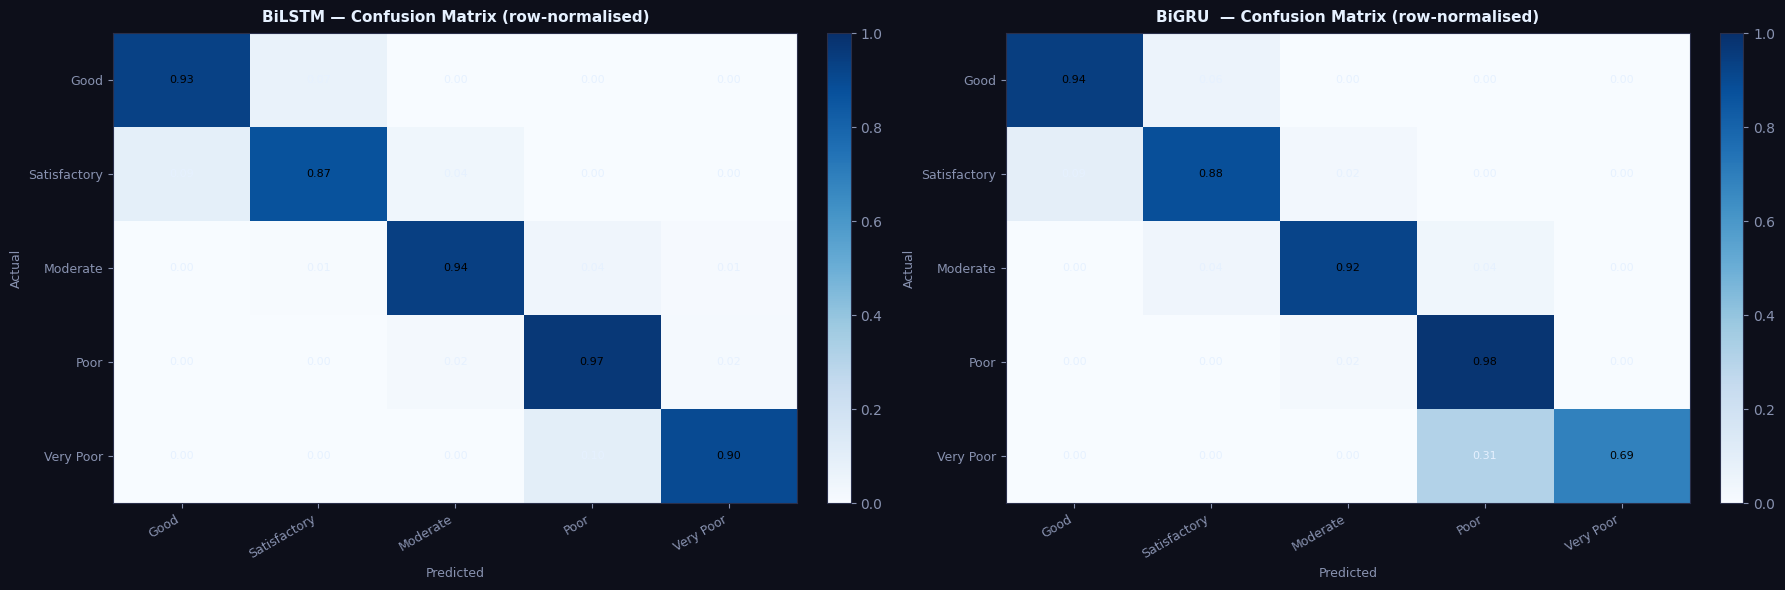

In [18]:
STATION_NAME = 'Patia'

# ── Side-by-side confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=DARK)

for ax, (ct, cp, pres), title in zip(
    axes,
    [(ct_lstm, cp_lstm, present_lstm), (ct_gru, cp_gru, present_gru)],
    [f'BiLSTM — Confusion Matrix (row-normalised) | {STATION_NAME}',
       f'BiGRU  — Confusion Matrix (row-normalised) | {STATION_NAME}']
):
    cm = confusion_matrix(ct, cp, labels=pres)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(pres)))
    ax.set_yticks(range(len(pres)))
    ax.set_xticklabels(pres, rotation=30, ha='right', color=MUTED, fontsize=9)
    ax.set_yticklabels(pres, color=MUTED, fontsize=9)
    ax.set_xlabel('Predicted', color=MUTED, fontsize=9)
    ax.set_ylabel('Actual',    color=MUTED, fontsize=9)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_facecolor(CARD)
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2f4a')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors=MUTED)

    thresh = 0.5
    for i in range(len(pres)):
        for j in range(len(pres)):
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if cm_norm[i,j] > thresh else WHITE)

plt.tight_layout()
plt.savefig(f'images/confusion_matrices_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

## 14. Model Comparison Dashboard

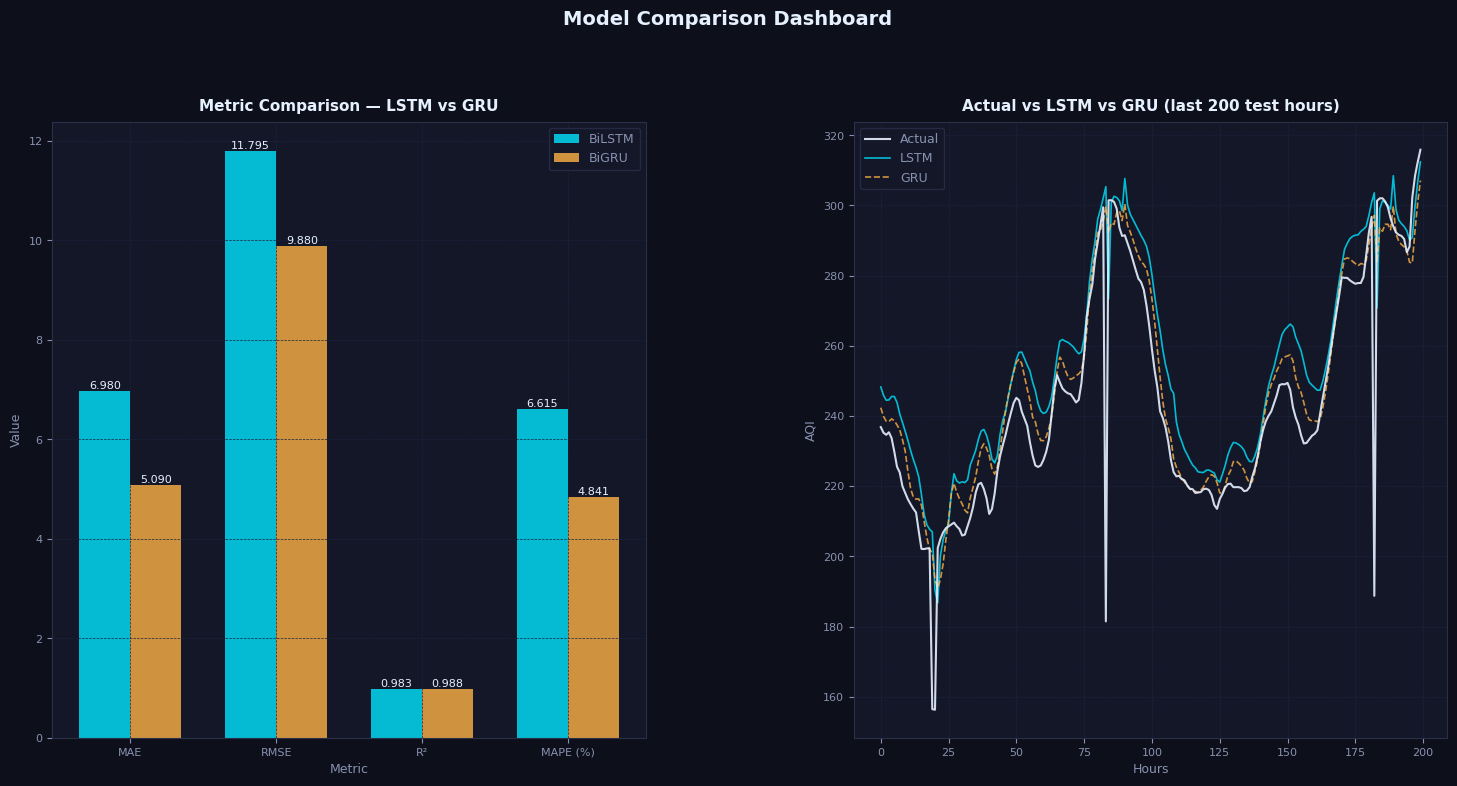

In [19]:
STATION_NAME = 'Patia'

# ── Radar + bar comparison ───────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# -- Bar chart: all metrics --------------------------------------------------
ax_bar = fig.add_subplot(gs[0])

metric_names = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
lstm_vals = [metrics_lstm['MAE'], metrics_lstm['RMSE'],
             metrics_lstm['R2'],  metrics_lstm['MAPE']]
gru_vals  = [metrics_gru['MAE'],  metrics_gru['RMSE'],
             metrics_gru['R2'],   metrics_gru['MAPE']]

x = np.arange(len(metric_names))
w = 0.35
b1 = ax_bar.bar(x - w/2, lstm_vals, w, color=ACC1, alpha=0.8, label='BiLSTM')
b2 = ax_bar.bar(x + w/2, gru_vals,  w, color=ACC4, alpha=0.8, label='BiGRU')

for bar in list(b1) + list(b2):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                color=WHITE, fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_names, color=MUTED)
style_ax(ax_bar, 'Metric Comparison — LSTM vs GRU', 'Metric', 'Value')
ax_bar.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

# -- Overlay time-series (last 200 hours of test) ----------------------------
ax_ts = fig.add_subplot(gs[1])
N = 200
ax_ts.plot(y_true_lstm[-N:], color=WHITE,  linewidth=1.5, label='Actual',  alpha=0.9, zorder=3)
ax_ts.plot(y_pred_lstm[-N:], color=ACC1,   linewidth=1.2, label='LSTM',    alpha=0.8, zorder=2)
ax_ts.plot(y_pred_gru[-N:],  color=ACC4,   linewidth=1.2, label='GRU',     alpha=0.8, zorder=2,
           linestyle='--')
style_ax(ax_ts, f'Actual vs LSTM vs GRU (last {N} test hours)', 'Hours', 'AQI')
ax_ts.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle(f'Model Comparison Dashboard | {STATION_NAME}', color=WHITE, fontsize=14,
             fontweight='bold', y=1.02)
plt.savefig(f'images/model_comparison_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

## 15. Save Models & Scalers

In [20]:
import joblib

# Save both models
lstm_model.save('saved_models/patia_lstm_model.keras')
gru_model.save('saved_models/patia_gru_model.keras')

# Save scalers (required for inference)
joblib.dump(feature_scaler, 'saved_models/patia_feature_scaler.pkl')
joblib.dump(target_scaler,  'saved_models/patia_target_scaler.pkl')

print('✅ LSTM model  →  patia_lstm_model.keras')
print('✅ GRU  model  →  patia_gru_model.keras')
print('✅ Scalers     →  patia_feature_scaler.pkl | patia_target_scaler.pkl')


✅ LSTM model  →  patia_lstm_model.keras
✅ GRU  model  →  patia_gru_model.keras
✅ Scalers     →  patia_feature_scaler.pkl | patia_target_scaler.pkl


In [21]:
# ── Inference helper ─────────────────────────────────────────────────────────
from tensorflow.keras.models import load_model

def predict_next_aqi(recent_df, model_path, feat_scaler, tgt_scaler,
                     features, look_back=48):
    """
    recent_df  : DataFrame with at least `look_back` rows and all feature columns.
    Returns    : predicted AQI (float) for the next hour.
    """
    model = load_model(model_path)
    scaled = feat_scaler.transform(recent_df[features].tail(look_back))
    x = scaled.reshape(1, look_back, len(features))
    pred_s = model.predict(x, verbose=0)
    return float(tgt_scaler.inverse_transform(pred_s)[0, 0])

# Quick sanity check using the last window from the test set
sample_df = data.iloc[-(LOOK_BACK + 1):-1]   # 48 rows
for mpath, label in [('saved_models/patia_lstm_model.keras', 'LSTM'),
                     ('saved_models/patia_gru_model.keras',  'GRU')]:
    pred = predict_next_aqi(sample_df, mpath,
                            feature_scaler, target_scaler, FEATURES)
    actual = data[TARGET].iloc[-1]
    print(f'{label:5s}  →  Predicted: {pred:.2f}   Actual: {actual:.2f}')


LSTM   →  Predicted: 312.41   Actual: 315.87
GRU    →  Predicted: 307.11   Actual: 315.87


---
## Summary

| Step | Detail |
|------|--------|
| Dataset | Patia, Bhubaneswar — Oct 2023 to Dec 2025 (~2.2 years) |
| Features | **EDA-recommended Patia set** — PM25, PM10, Benzene, Eth-Benzene, MP-Xylene, NO2, AT, RH + lag/rolling/derived |
| Target | AQI (next hour) |
| Scaling | **MinMaxScaler [0, 1]** (EDA Section 15 recommendation) |
| Look-back window | **48 hours** (EDA ACF Section 13: significant up to ~48 h) |
| LSTM architecture | BiLSTM(128) → LSTM(64) → BN → Dense(32→16→1) |
| GRU  architecture | BiGRU(128) → GRU(64) → BN → Dense(32→16→1) |
| Optimizer | Adam (lr=0.001) |
| Loss | MSE |
| Train/Val/Test | 70% / 15% / 15% |
| Batch size | **32** (EDA: smaller batches for shorter record) |
| Callbacks | EarlyStopping(**10**), ReduceLROnPlateau(5), ModelCheckpoint |

### Feature Set (EDA Section 18 — Patia, Bhubaneswar)

| Tier | Features | Count |
|------|----------|-------|
| Tier 1 | PM25, PM10, Benzene, Eth-Benzene, MP-Xylene, lag_1, lag_6, lag_24, roll_mean_6, roll_mean_24, ema_24 | 11 |
| Tier 2 | NO2, NOx, SO2, O3, NH3, CO, AT, RH, WS, RF, SR, hour_sin, hour_cos, month_sin, month_cos | 15 |
| Tier 3 | dow_sin, dow_cos, is_weekend, ema_6, roll_std_24, diff_1, AT_RH_stability, BTEX_total | 8 |
| Dropped | BP, Toluene_Benzene_ratio, diff_24, roll_std_6 | — |

### EDA-to-Model Alignment — Patia

| EDA Finding | Model Implementation |
|---|---|
| PM2.5 (r=0.949), PM10 (r=0.916) dominant | Tier 1 features |
| Benzene (r=0.770), MP-Xylene (r=0.635), Eth-Benzene (r=0.575) | Tier 1 VOC features (unique to Patia) |
| AT (r=−0.635) strongest negative predictor | Tier 2; also used in AT_RH_stability |
| ACF significant up to 48h | LOOK_BACK = 48; lag_1/6/24 |
| Diurnal peak at 16:00 (afternoon traffic) | hour_sin / hour_cos |
| Strong seasonal pattern (Dec–Jan worst) | month_sin / month_cos |
| Short record (~2.2 years) | BATCH_SIZE=32; EarlyStopping patience=10 |
| MinMaxScaler recommended | MinMaxScaler [0, 1] |
| Boundary-layer stability key driver | AT_RH_stability derived feature |

### Possible Further Improvements
- Attention mechanism over LSTM/GRU hidden states
- Temporal Fusion Transformer for multi-step forecasting
- Multi-step ahead forecasting (2-h, 6-h, 12-h) — important for Patia's severe winter episodes
- Include WD (wind direction, sin/cos encoded) if available
- Ensemble: average LSTM + GRU predictions
- Stratified evaluation by season (winter vs monsoon) given Patia's extreme seasonal contrast
- Consider augmenting data or transfer learning given the shorter record length
